## 1.Các thư viện cần thiết

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans
import re
import seaborn as sns
# Tiền xử lý
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
# Machine Learning - giám sát & không giám sát
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Semi-supervised learning
from sklearn.semi_supervised import SelfTrainingClassifier, LabelPropagation
# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
# Học biểu diễn (Representation Learning)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# Giải thích mô hình
import shap
# Cảnh báo
import warnings
warnings.filterwarnings('ignore')
  


## 2.Thu thập và khám phá dữ liệu

2.1 Tải và kiểm tra dữ liệu ban đầu

In [ ]:
# Đường dẫn tới thư mục chứa các file CSV
folder_path = 'D:\IT\Đồ án 2\PRJ\data' 

# Lấy danh sách tất cả file CSV trong thư mục
csv_files = [file for file in os.listdir(folder_path) if file.endswith('.csv')]

# Đọc từng file CSV vào một DataFrame, rồi gộp lại
all_dataframes = []
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    full_data = pd.read_csv(file_path)
    all_dataframes.append(full_data)

# Gộp toàn bộ dữ liệu thành một DataFrame
full_data = pd.concat(all_dataframes, ignore_index=True)
print(f"Dữ liệu đã được tải với {full_data.shape[0]} dòng và {full_data.shape[1]} cột.")

Dữ liệu đã được tải với 1103170 dòng và 10 cột.


In [33]:
# Thông tin cơ bản
print("===== THÔNG TIN CƠ BẢN =====")
print(full_data.info())

===== THÔNG TIN CƠ BẢN =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1103170 entries, 0 to 1103169
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   name            1103170 non-null  object 
 1   main_category   1103170 non-null  object 
 2   sub_category    1103170 non-null  object 
 3   image           1103170 non-null  object 
 4   link            1103170 non-null  object 
 5   ratings         751582 non-null   object 
 6   no_of_ratings   751582 non-null   object 
 7   discount_price  980844 non-null   object 
 8   actual_price    1067544 non-null  object 
 9   Unnamed: 0      551585 non-null   float64
dtypes: float64(1), object(9)
memory usage: 84.2+ MB
None


2.2 Kiểm tra chất lượng dữ liệu

In [34]:
# Kiểm tra giá trị thiếu
print("===== KIỂM TRA GIÁ TRỊ THIẾU =====")
missing_values = full_data.isnull().sum()
missing_percent = (missing_values / len(full_data)) * 100
missing_data = pd.concat([missing_values, missing_percent], axis=1)
missing_data.columns = ['Số lượng', 'Phần trăm (%)']
print(missing_data[missing_data['Số lượng'] > 0])

===== KIỂM TRA GIÁ TRỊ THIẾU =====
                Số lượng  Phần trăm (%)
ratings           351588      31.870700
no_of_ratings     351588      31.870700
discount_price    122326      11.088590
actual_price       35626       3.229421
Unnamed: 0        551585      50.000000


## 3.Tiền xử lý dữ liệu

In [35]:
# Tạo bản sao để tránh thay đổi dữ liệu gốc
full_data_processed = full_data.copy()

In [36]:
# Xử lý các cột image, link, Unnamed: 0 - do không cần thiết cho việc dự đoán
columns_to_drop = ['image', 'link', 'Unnamed: 0']
full_data = full_data.drop(columns=columns_to_drop, errors='ignore')

# Hiển thị vài dòng đầu để kiểm tra
display(full_data.head())

,name,main_category,sub_category,ratings,no_of_ratings,discount_price,actual_price
0,Lloyd 1.5 Ton 3 Star Inverter Split Ac (5 In 1...,appliances,Air Conditioners,4.2,"2,255","₹32,999","₹58,990"
1,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,4.2,"2,948","₹46,490","₹75,990"
2,LG 1 Ton 4 Star Ai Dual Inverter Split Ac (Cop...,appliances,Air Conditioners,4.2,"1,206","₹34,490","₹61,990"
3,LG 1.5 Ton 3 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,4.0,69,"₹37,990","₹68,990"
4,Carrier 1.5 Ton 3 Star Inverter Split AC (Copp...,appliances,Air Conditioners,4.1,630,"₹34,490","₹67,790"


In [37]:
# Xử lý giá trị thiếu
# - Chuyển đổi các cột ratings và no_of_ratings sang kiểu số, ép các giá trị không hợp lệ thành NaN
full_data['ratings'] = pd.to_numeric(full_data['ratings'], errors='coerce')
full_data['no_of_ratings'] = pd.to_numeric(full_data['no_of_ratings'], errors='coerce')

# - Thay thế các giá trị NaN bằng trung vị của từng cột
full_data['ratings'].fillna(full_data['ratings'].median(), inplace=True)
full_data['no_of_ratings'].fillna(full_data['no_of_ratings'].median(), inplace=True)

# - Xóa hàng nếu discount_price hoặc actual_price thiếu
full_data.dropna(subset=['discount_price', 'actual_price'], inplace=True)

In [38]:
# Kiểm tra các giá trị NaN hoặc thiếu
nan_counts = full_data.isnull().sum()
nan_percentage = (nan_counts / len(full_data)) * 100

# Tạo DataFrame để hiển thị kết quả
nan_summary = pd.DataFrame({
    'Số lượng NaN': nan_counts,
    'Phần trăm (%)': nan_percentage
}).sort_values(by='Số lượng NaN', ascending=False)

# Hiển thị các cột có giá trị NaN
print("Tóm tắt các giá trị NaN:")
display(nan_summary[nan_summary['Số lượng NaN'] > 0])

Tóm tắt các giá trị NaN:


,Số lượng NaN,Phần trăm (%)


In [39]:
# 3. Xử lý cột ratings
# Kiểm tra các giá trị duy nhất trong cột ratings
print("\nCác giá trị duy nhất trong cột ratings:")
print(full_data['ratings'].unique())


Các giá trị duy nhất trong cột ratings:
[4.2 4.  4.1 4.3 3.9 3.8 3.5 4.6 3.3 3.4 3.7 2.9 5.  4.4 3.6 2.7 4.5 3.
 3.1 4.8 4.7 3.2 2.5 1.  2.6 2.8 1.7 1.8 2.4 4.9 2.2 1.6 1.9 2.3 2.  1.4
 2.1 1.2 1.3 1.5 1.1]


In [40]:
# Hàm kiểm tra giá trị bất thường bằng IQR
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Lọc các giá trị bất thường
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    print(f"Số lượng giá trị bất thường trong cột {column}: {len(outliers)}")
    return outliers


In [41]:
# Chuyển đổi các cột giá trị tiền tệ sang kiểu số
full_data['discount_price'] = full_data['discount_price'].replace('[₹,]', '', regex=True).astype(float)
full_data['actual_price'] = full_data['actual_price'].replace('[₹,]', '', regex=True).astype(float)

# Kiểm tra giá trị bất thường cho các cột số
numeric_columns = ['ratings', 'no_of_ratings', 'discount_price', 'actual_price']
for col in numeric_columns:
    print(f"\nKiểm tra giá trị bất thường cho cột {col}:")
    outliers = detect_outliers(full_data, col)
    if not outliers.empty:
        display(outliers.head())


Kiểm tra giá trị bất thường cho cột ratings:
Số lượng giá trị bất thường trong cột ratings: 212466


,name,main_category,sub_category,ratings,no_of_ratings,discount_price,actual_price
30,"Voltas 2 Ton 3 Star, Inverter Split AC(Copper,...",appliances,Air Conditioners,4.6,3.0,44990.0,79990.0
40,"Samsung 1 Ton 3 Star Wi-fi Enabled, Wind-Free ...",appliances,Air Conditioners,4.6,8.0,34699.0,53990.0
49,"Voltas 1 Ton 3 Star, Inverter Split AC(Copper,...",appliances,Air Conditioners,2.9,5.0,29950.0,56990.0
58,Hitachi Split Ac - 1.5 Ton Kiyora 5200Fx I Fre...,appliances,Air Conditioners,5.0,1.0,42240.0,71900.0
74,LG 2.0 Ton 3 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,2.7,3.0,52900.0,85990.0



Kiểm tra giá trị bất thường cho cột no_of_ratings:
Số lượng giá trị bất thường trong cột no_of_ratings: 177530


,name,main_category,sub_category,ratings,no_of_ratings,discount_price,actual_price
3,LG 1.5 Ton 3 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,4.0,69.0,37990.0,68990.0
4,Carrier 1.5 Ton 3 Star Inverter Split AC (Copp...,appliances,Air Conditioners,4.1,630.0,34490.0,67790.0
8,Carrier 1 Ton 3 Star AI Flexicool Inverter Spl...,appliances,Air Conditioners,4.1,674.0,30990.0,58190.0
9,"Voltas 1.5 Ton, 5 Star, Inverter Split AC(Copp...",appliances,Air Conditioners,4.0,801.0,37999.0,73990.0
10,"Daikin 1 Ton 3 Star Inverter Split AC (Copper,...",appliances,Air Conditioners,4.2,558.0,32990.0,48200.0



Kiểm tra giá trị bất thường cho cột discount_price:
Số lượng giá trị bất thường trong cột discount_price: 122982


,name,main_category,sub_category,ratings,no_of_ratings,discount_price,actual_price
0,Lloyd 1.5 Ton 3 Star Inverter Split Ac (5 In 1...,appliances,Air Conditioners,4.2,15.0,32999.0,58990.0
1,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,4.2,15.0,46490.0,75990.0
2,LG 1 Ton 4 Star Ai Dual Inverter Split Ac (Cop...,appliances,Air Conditioners,4.2,15.0,34490.0,61990.0
3,LG 1.5 Ton 3 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,4.0,69.0,37990.0,68990.0
4,Carrier 1.5 Ton 3 Star Inverter Split AC (Copp...,appliances,Air Conditioners,4.1,630.0,34490.0,67790.0



Kiểm tra giá trị bất thường cho cột actual_price:
Số lượng giá trị bất thường trong cột actual_price: 107988


,name,main_category,sub_category,ratings,no_of_ratings,discount_price,actual_price
0,Lloyd 1.5 Ton 3 Star Inverter Split Ac (5 In 1...,appliances,Air Conditioners,4.2,15.0,32999.0,58990.0
1,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,4.2,15.0,46490.0,75990.0
2,LG 1 Ton 4 Star Ai Dual Inverter Split Ac (Cop...,appliances,Air Conditioners,4.2,15.0,34490.0,61990.0
3,LG 1.5 Ton 3 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,4.0,69.0,37990.0,68990.0
4,Carrier 1.5 Ton 3 Star Inverter Split AC (Copp...,appliances,Air Conditioners,4.1,630.0,34490.0,67790.0


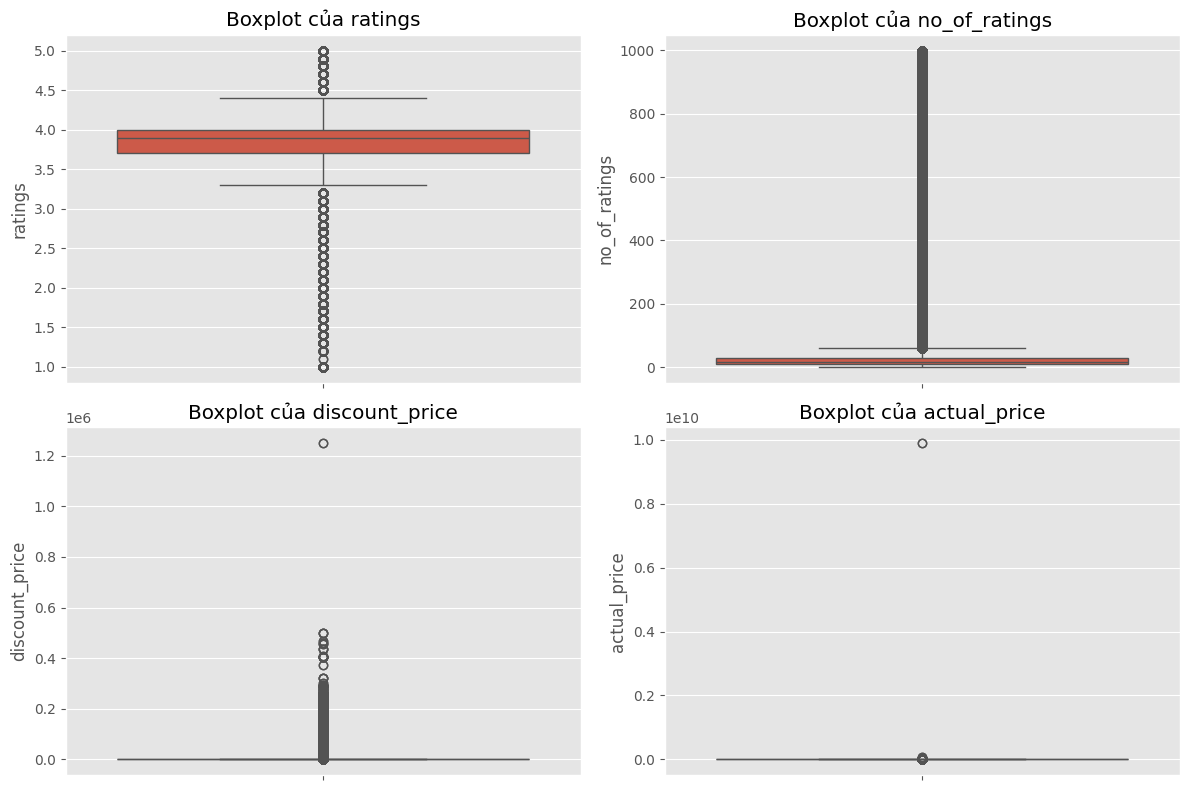

In [42]:
# Vẽ biểu đồ boxplot cho các cột số
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=full_data, y=col)
    plt.title(f'Boxplot của {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [43]:
# Hàm xử lý giá trị bất thường bằng IQR
def handle_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Giới hạn giá trị bất thường (capping)
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
    return data

# Xử lý giá trị bất thường cho các cột số
for col in numeric_columns:
    full_data = handle_outliers(full_data, col)

# Kiểm tra lại thống kê sau khi xử lý
print("\nTóm tắt thống kê sau khi xử lý giá trị bất thường:")
print(full_data[numeric_columns].describe())


Tóm tắt thống kê sau khi xử lý giá trị bất thường:
             ratings  no_of_ratings  discount_price   actual_price
count  980844.000000  980844.000000   980844.000000  980844.000000
mean        3.877689      22.100405     1044.790876    2258.255153
std         0.346018      19.899576      893.902622    1785.000318
min         3.250000       1.000000        8.000000      10.000000
25%         3.700000       9.000000      389.000000     999.000000
50%         3.900000      15.000000      679.000000    1599.000000
75%         4.000000      29.000000     1399.000000    2999.000000
max         4.450000      59.000000     2914.000000    5999.000000


In [44]:
# Kiểm tra lại các giá trị bất thường cho các cột số
print("===== KIỂM TRA LẠI GIÁ TRỊ BẤT THƯỜNG =====")
for col in numeric_columns:
    print(f"\nKiểm tra giá trị bất thường cho cột {col}:")
    outliers = detect_outliers(full_data, col)
    if not outliers.empty:
        display(outliers.head())
    else:
        print(f"Không có giá trị bất thường trong cột {col}.")

===== KIỂM TRA LẠI GIÁ TRỊ BẤT THƯỜNG =====

Kiểm tra giá trị bất thường cho cột ratings:
Số lượng giá trị bất thường trong cột ratings: 0
Không có giá trị bất thường trong cột ratings.

Kiểm tra giá trị bất thường cho cột no_of_ratings:
Số lượng giá trị bất thường trong cột no_of_ratings: 0
Không có giá trị bất thường trong cột no_of_ratings.

Kiểm tra giá trị bất thường cho cột discount_price:
Số lượng giá trị bất thường trong cột discount_price: 0
Không có giá trị bất thường trong cột discount_price.

Kiểm tra giá trị bất thường cho cột actual_price:
Số lượng giá trị bất thường trong cột actual_price: 0
Không có giá trị bất thường trong cột actual_price.


In [45]:
# 7. Kiểm tra và xóa dữ liệu trùng lặp
print("Số hàng trùng lặp:", full_data.duplicated().sum())
full_data = full_data.drop_duplicates()
print(f"Đã xóa số hàng trùng lặp")

Số hàng trùng lặp: 529349
Đã xóa số hàng trùng lặp


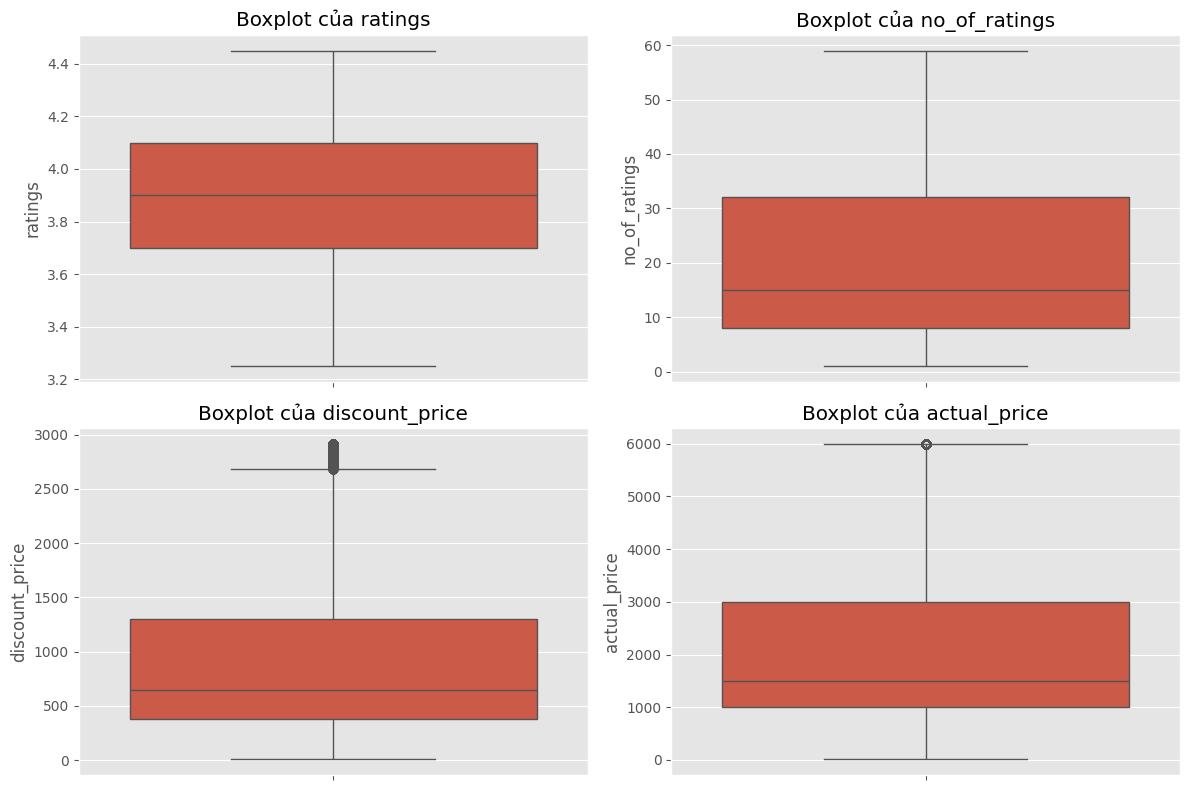

In [46]:
# Vẽ lại biểu đồ boxplot cho các cột số
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=full_data, y=col)
    plt.title(f'Boxplot của {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# Giải thích ý nghĩa của 4 boxplot cho các cột số
### Giải thích 4 boxplot cho các cột số:

1. **ratings**: Boxplot thể hiện phần lớn sản phẩm có điểm đánh giá tập trung quanh giá trị trung bình (khoảng 3.8–4.2), rất ít sản phẩm bị đánh giá thấp hoặc quá cao. Không có nhiều giá trị ngoại lai.

2. **no_of_ratings**: Số lượng đánh giá phân bố lệch phải, đa số sản phẩm chỉ có ít đánh giá, một số ít sản phẩm rất nổi bật với số lượng đánh giá cao (các điểm ngoại lai).

3. **discount_price**: Giá sau giảm đa phần tập trung ở mức thấp đến trung bình, nhưng vẫn có một số sản phẩm giá rất cao (outlier). Điều này phản ánh sự đa dạng về phân khúc giá.

4. **actual_price**: Giá gốc cũng có phân phối lệch phải, nhiều sản phẩm giá rẻ, một số ít sản phẩm giá rất cao (outlier). Điều này cho thấy thị trường có nhiều sản phẩm cao cấp bên cạnh sản phẩm phổ thông.

**Tóm lại:** Các boxplot giúp nhận diện sự phân bố, phát hiện giá trị bất thường và hiểu rõ hơn về đặc trưng dữ liệu số trong bộ dữ liệu sản phẩm.
"""


In [47]:
# 8. Chuẩn hóa văn bản
full_data['name'] = full_data['name'].str.lower().str.strip()
full_data['main_category'] = full_data['main_category'].str.lower().str.strip()
full_data['sub_category'] = full_data['sub_category'].str.lower().str.strip()

In [48]:
# 9. Tạo cột mới: Tính phần trăm giảm giá
full_data['discount_percentage'] = ((full_data['actual_price'] - full_data['discount_price']) / full_data['actual_price'] * 100).round(2)

# Hiển thị thông tin DataFrame sau tiền xử lý
print("\nThông tin DataFrame sau tiền xử lý:")
print(full_data.info())

# Hiển thị vài dòng đầu
display(full_data.head())


Thông tin DataFrame sau tiền xử lý:
<class 'pandas.core.frame.DataFrame'>
Index: 451495 entries, 0 to 580336
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   name                 451495 non-null  object 
 1   main_category        451495 non-null  object 
 2   sub_category         451495 non-null  object 
 3   ratings              451495 non-null  float64
 4   no_of_ratings        451495 non-null  float64
 5   discount_price       451495 non-null  float64
 6   actual_price         451495 non-null  float64
 7   discount_percentage  451495 non-null  float64
dtypes: float64(5), object(3)
memory usage: 31.0+ MB
None


,name,main_category,sub_category,ratings,no_of_ratings,discount_price,actual_price,discount_percentage
0,lloyd 1.5 ton 3 star inverter split ac (5 in 1...,appliances,air conditioners,4.2,15.0,2914.0,5999.0,51.43
1,lg 1.5 ton 5 star ai dual inverter split ac (c...,appliances,air conditioners,4.2,15.0,2914.0,5999.0,51.43
2,lg 1 ton 4 star ai dual inverter split ac (cop...,appliances,air conditioners,4.2,15.0,2914.0,5999.0,51.43
3,lg 1.5 ton 3 star ai dual inverter split ac (c...,appliances,air conditioners,4.0,59.0,2914.0,5999.0,51.43
4,carrier 1.5 ton 3 star inverter split ac (copp...,appliances,air conditioners,4.1,59.0,2914.0,5999.0,51.43


## 4.EDA - Phân tích khám phá dữ liệu kết hợp học không giám sát

In [49]:
# Thiết lập kiểu hiển thị cho biểu đồ
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Tóm tắt thống kê
print("Tóm tắt thống kê của các cột số:")
print(full_data[['ratings', 'no_of_ratings', 'discount_price', 'actual_price', 'discount_percentage']].describe())

# 2. Phân tích theo nhóm
# - Đánh giá trung bình và số lượng đánh giá theo main_category
category_stats = full_data.groupby('main_category').agg({
    'ratings': 'mean',
    'no_of_ratings': 'sum',
    'discount_price': 'mean',
    'discount_percentage': 'mean'
}).reset_index()
print("\nThống kê theo main_category:")
print(category_stats)

# - Top 5 danh mục có đánh giá trung bình cao nhất
top_rated_categories = category_stats.sort_values(by='ratings', ascending=False).head(5)
print("\nTop 5 danh mục có đánh giá trung bình cao nhất:")
print(top_rated_categories[['main_category', 'ratings']])


Tóm tắt thống kê của các cột số:
             ratings  no_of_ratings  discount_price   actual_price  \
count  451495.000000  451495.000000   451495.000000  451495.000000   
mean        3.876230      22.372004      995.876724    2166.513503   
std         0.352828      20.226927      856.774447    1717.739361   
min         3.250000       1.000000        8.000000      10.000000   
25%         3.700000       8.000000      379.000000     995.000000   
50%         3.900000      15.000000      649.000000    1500.000000   
75%         4.100000      32.000000     1299.000000    2995.000000   
max         4.450000      59.000000     2914.000000    5999.000000   

       discount_percentage  
count        451495.000000  
mean             51.404090  
std              19.613374  
min               0.000000  
25%              40.020000  
50%              51.430000  
75%              65.960000  
max              99.830000  

Thống kê theo main_category:
              main_category   ratings  no_of_

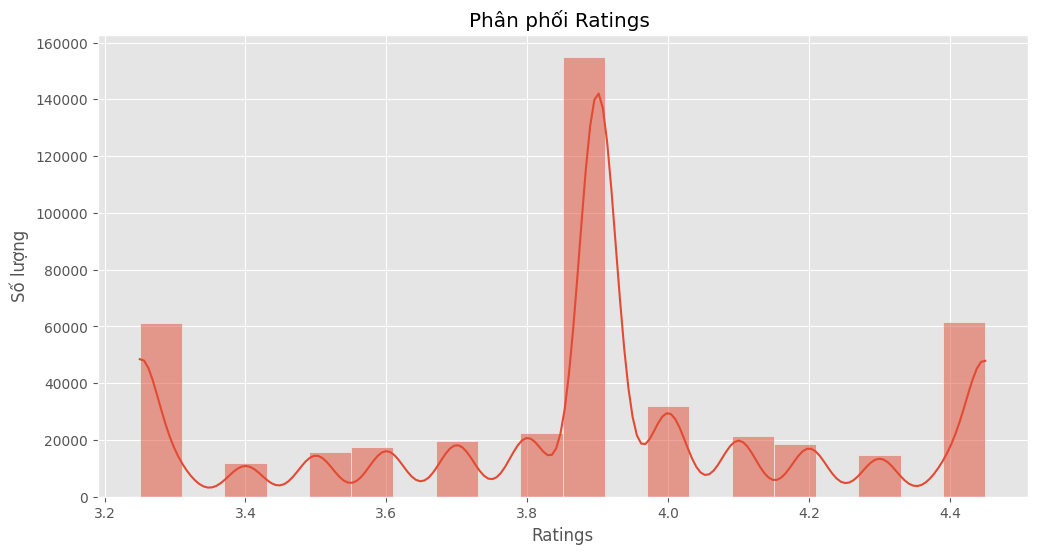

In [50]:
# 3. Biểu đồ trực quan
# - Phân phối của ratings
plt.figure()
sns.histplot(full_data['ratings'], bins=20, kde=True)
plt.title('Phân phối Ratings ')
plt.xlabel('Ratings')
plt.ylabel('Số lượng')
plt.show()


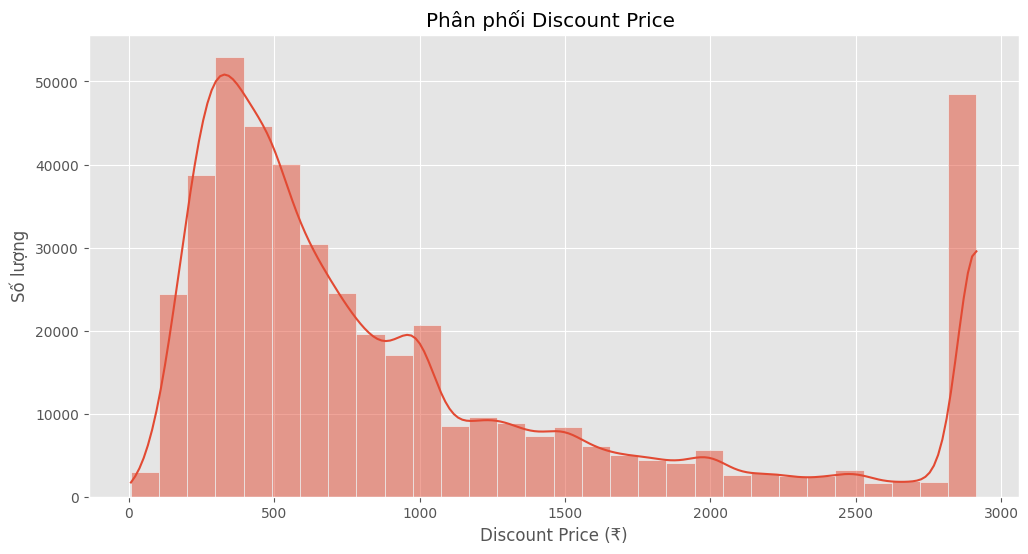

In [51]:
# - Phân phối của discount_price
plt.figure()
sns.histplot(full_data['discount_price'], bins=30, kde=True)
plt.title('Phân phối Discount Price ')
plt.xlabel('Discount Price (₹)')
plt.ylabel('Số lượng')
plt.show()

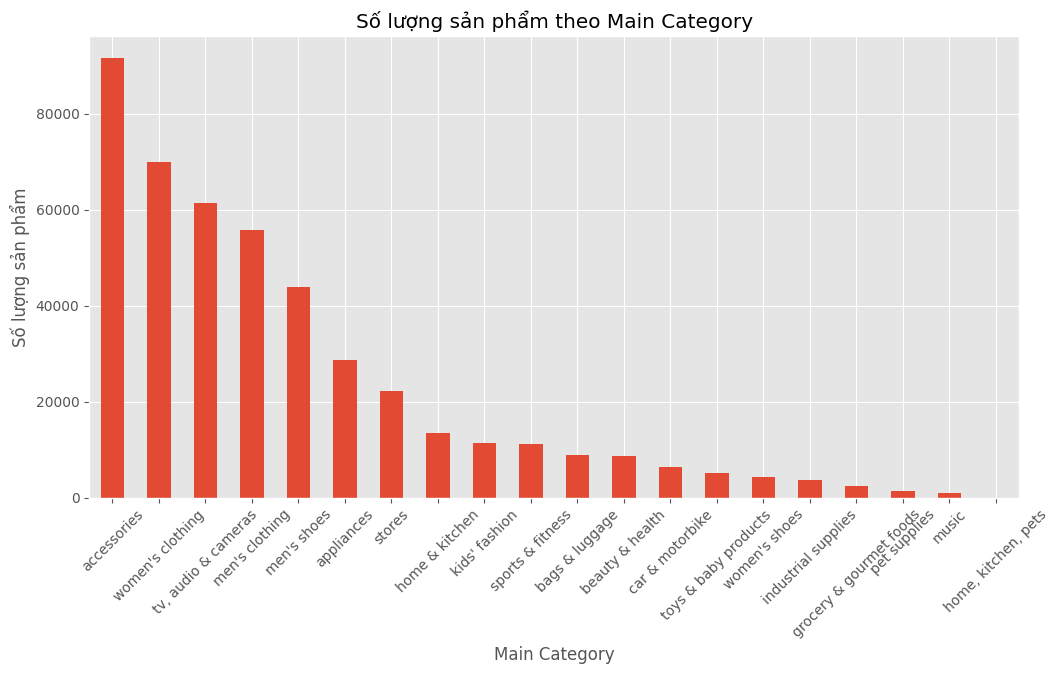

In [52]:
# - Số lượng sản phẩm theo main_category
plt.figure()
full_data['main_category'].value_counts().plot(kind='bar')
plt.title('Số lượng sản phẩm theo Main Category')
plt.xlabel('Main Category')
plt.ylabel('Số lượng sản phẩm')
plt.xticks(rotation=45)
plt.show()

In [53]:
# 4. Phân tích tương quan
# - Ma trận tương quan
correlation_matrix = full_data[['ratings', 'no_of_ratings', 'discount_price', 'actual_price', 'discount_percentage']].corr()
print("\nMa trận tương quan:")
print(correlation_matrix)



Ma trận tương quan:
                      ratings  no_of_ratings  discount_price  actual_price  \
ratings              1.000000       0.000470        0.101677      0.064745   
no_of_ratings        0.000470       1.000000       -0.035774     -0.019211   
discount_price       0.101677      -0.035774        1.000000      0.884765   
actual_price         0.064745      -0.019211        0.884765      1.000000   
discount_percentage -0.105877       0.021899       -0.218413      0.169140   

                     discount_percentage  
ratings                        -0.105877  
no_of_ratings                   0.021899  
discount_price                 -0.218413  
actual_price                    0.169140  
discount_percentage             1.000000  


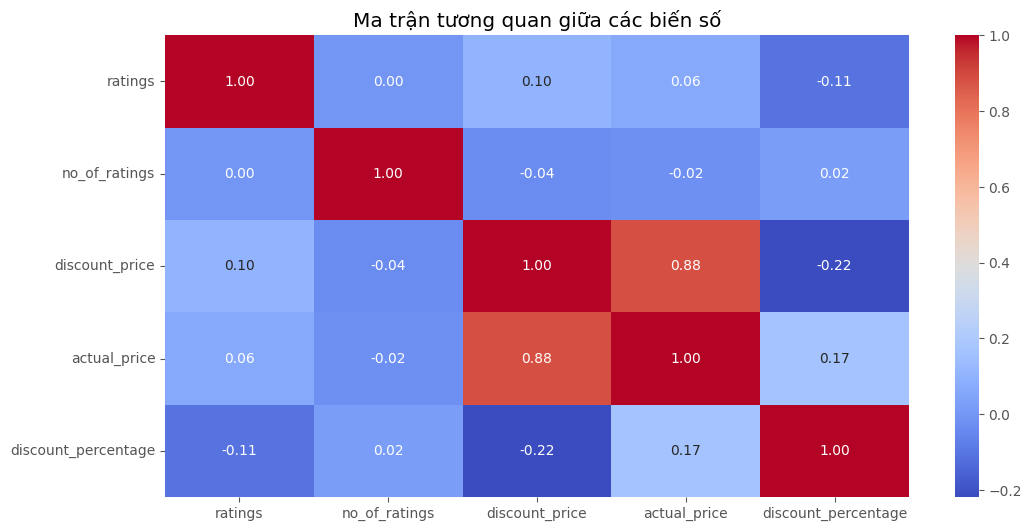

In [54]:
# - Heatmap của ma trận tương quan
plt.figure()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

Một số cặp biến nổi bật trong ma trận tương quan:
- discount_price & actual_price: Hệ số tương quan rất cao (≈ 0.88), cho thấy giá sau giảm và giá gốc tăng/giảm cùng chiều, hợp lý vì discount_price thường được tính từ actual_price.
- discount_percentage có tương quan âm với discount_price (≈ -0.22), nghĩa là sản phẩm càng giảm giá nhiều thì giá sau giảm càng thấp.
- ratings và các biến khác có tương quan yếu, cho thấy điểm đánh giá không phụ thuộc nhiều vào giá hoặc số lượng đánh giá.
""")

In [55]:
# Tạo nhận xét cho từng cặp biến trong ma trận tương quan dưới dạng markdown
markdown_explanation = "### Nhận xét các cặp biến trong ma trận tương quan:\n"
checked_pairs = set()
for var1 in corr_matrix.columns:
    for var2 in corr_matrix.columns:
        if var1 != var2 and (var2, var1) not in checked_pairs:
            corr_value = corr_matrix.loc[var1, var2]
            if abs(corr_value) >= 0.7:
                relation = "tương quan mạnh"
            elif abs(corr_value) >= 0.3:
                relation = "tương quan vừa"
            elif abs(corr_value) > 0:
                relation = "tương quan yếu"
            else:
                relation = "không tương quan"
            direction = "cùng chiều" if corr_value > 0 else ("ngược chiều" if corr_value < 0 else "")
            markdown_explanation += f"- **{var1}** & **{var2}**: Hệ số = **{corr_value:.2f}** ({relation}{', ' + direction if direction else ''})\n"
            checked_pairs.add((var1, var2))
display(Markdown(markdown_explanation))

### Nhận xét các cặp biến trong ma trận tương quan:
- **ratings** & **no_of_ratings**: Hệ số = **0.00** (tương quan yếu, cùng chiều)
- **ratings** & **discount_price**: Hệ số = **0.10** (tương quan yếu, cùng chiều)
- **ratings** & **actual_price**: Hệ số = **0.06** (tương quan yếu, cùng chiều)
- **ratings** & **discount_percentage**: Hệ số = **-0.11** (tương quan yếu, ngược chiều)
- **no_of_ratings** & **discount_price**: Hệ số = **-0.04** (tương quan yếu, ngược chiều)
- **no_of_ratings** & **actual_price**: Hệ số = **-0.02** (tương quan yếu, ngược chiều)
- **no_of_ratings** & **discount_percentage**: Hệ số = **0.02** (tương quan yếu, cùng chiều)
- **discount_price** & **actual_price**: Hệ số = **0.88** (tương quan mạnh, cùng chiều)
- **discount_price** & **discount_percentage**: Hệ số = **-0.22** (tương quan yếu, ngược chiều)
- **actual_price** & **discount_percentage**: Hệ số = **0.17** (tương quan yếu, cùng chiều)


In [56]:
# 1. Phân tích các danh mục phổ biến
popular_categories = full_data['main_category'].value_counts()
print("Các danh mục phổ biến:")
display(popular_categories.head(10))

# 2. Lựa chọn sản phẩm phổ biến
# - Sản phẩm có số lượng đánh giá cao nhất
popular_products = full_data.sort_values(by='no_of_ratings', ascending=False).head(10)
print("\nTop 10 sản phẩm phổ biến dựa trên số lượng đánh giá:")
display(popular_products[['name', 'main_category', 'ratings', 'no_of_ratings']])

Các danh mục phổ biến:


main_category
accessories            91618
women's clothing       69884
tv, audio & cameras    61475
men's clothing         55779
men's shoes            43837
appliances             28714
stores                 22183
home & kitchen         13425
kids' fashion          11357
sports & fitness       11263
Name: count, dtype: int64


Top 10 sản phẩm phổ biến dựa trên số lượng đánh giá:


,name,main_category,ratings,no_of_ratings
32,"whirlpool 1.0 ton 3 star, flexicool inverter s...",appliances,3.9,59.0
3,lg 1.5 ton 3 star ai dual inverter split ac (c...,appliances,4.0,59.0
4,carrier 1.5 ton 3 star inverter split ac (copp...,appliances,4.1,59.0
8,carrier 1 ton 3 star ai flexicool inverter spl...,appliances,4.1,59.0
9,"voltas 1.5 ton, 5 star, inverter split ac(copp...",appliances,4.0,59.0
10,"daikin 1 ton 3 star inverter split ac (copper,...",appliances,4.2,59.0
398863,clovia women's pack of 3 full coverage non pad...,women's clothing,3.5,59.0
29,"godrej 1.5 ton 3 star 5-in-1 convertible, inve...",appliances,3.9,59.0
36,"daikin 1 ton 5 star inverter split ac (copper,...",appliances,4.1,59.0
38,blue star 1 ton 3 star fixed speed window ac (...,appliances,4.0,59.0


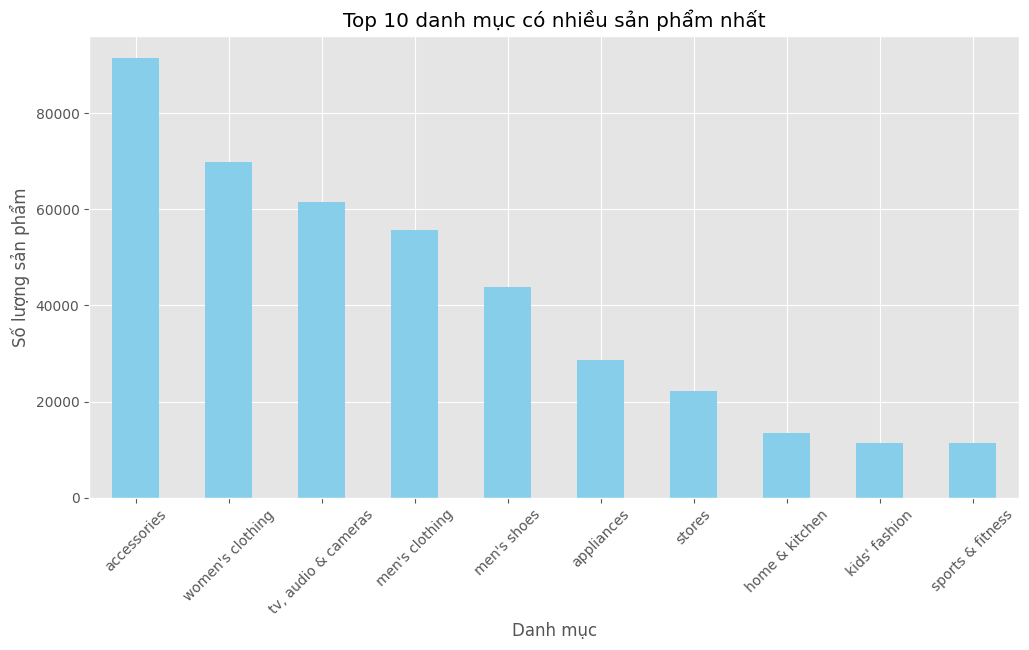

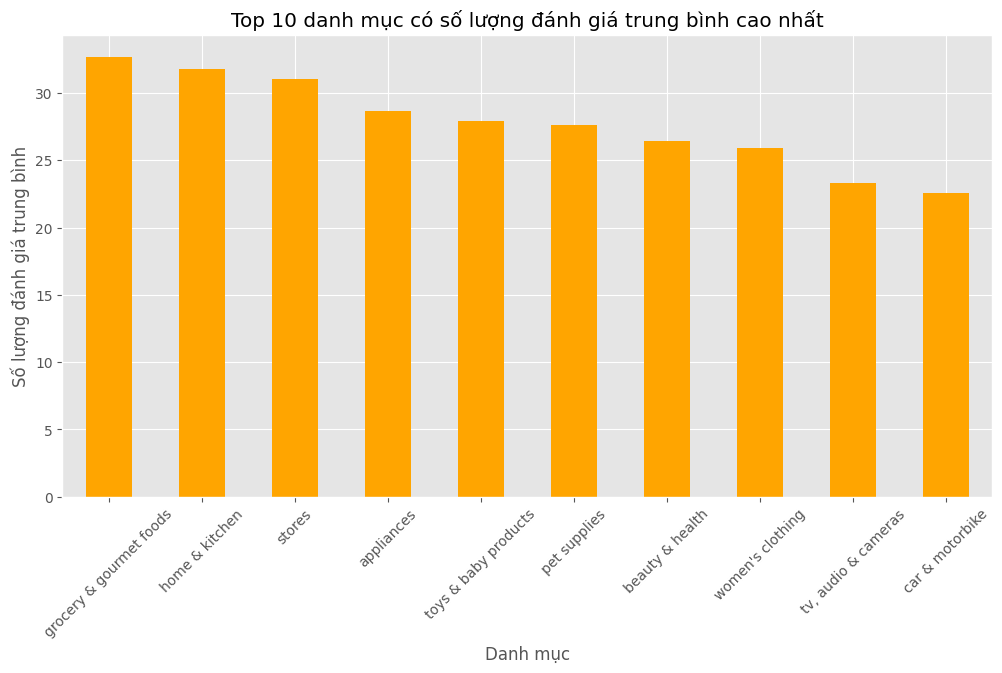

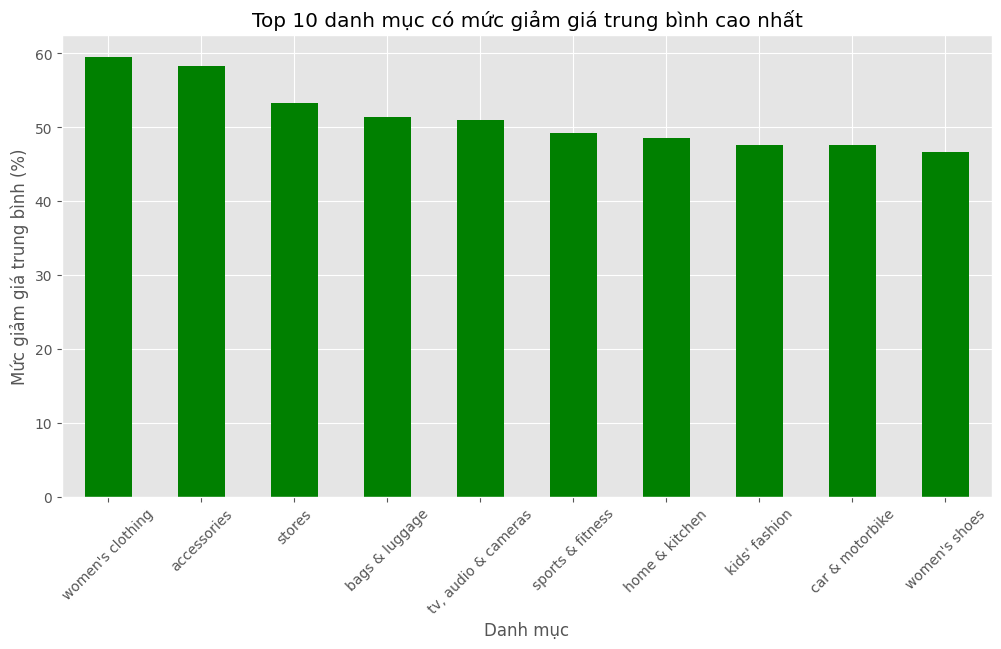

In [57]:
# 1. Phân tích số lượng sản phẩm theo danh mục chính
product_count_by_category = full_data['main_category'].value_counts()
# 2. Phân tích số lượng đánh giá trung bình theo danh mục
average_ratings_by_category = full_data.groupby('main_category')['no_of_ratings'].mean().sort_values(ascending=False)
# 3. Phân tích mức giảm giá trung bình theo danh mục
average_discount_by_category = full_data.groupby('main_category')['discount_percentage'].mean().sort_values(ascending=False)
# 4. Trực quan hóa
# Biểu đồ số lượng sản phẩm
plt.figure(figsize=(12, 6))
product_count_by_category.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 danh mục có nhiều sản phẩm nhất')
plt.xlabel('Danh mục')
plt.ylabel('Số lượng sản phẩm')
plt.xticks(rotation=45)
plt.show()
# Biểu đồ số lượng đánh giá trung bình
plt.figure(figsize=(12, 6))
average_ratings_by_category.head(10).plot(kind='bar', color='orange')
plt.title('Top 10 danh mục có số lượng đánh giá trung bình cao nhất')
plt.xlabel('Danh mục')
plt.ylabel('Số lượng đánh giá trung bình')
plt.xticks(rotation=45)
plt.show()
# Biểu đồ mức giảm giá trung bình
plt.figure(figsize=(12, 6))
average_discount_by_category.head(10).plot(kind='bar', color='green')
plt.title('Top 10 danh mục có mức giảm giá trung bình cao nhất')
plt.xlabel('Danh mục')
plt.ylabel('Mức giảm giá trung bình (%)')
plt.xticks(rotation=45)
plt.show()

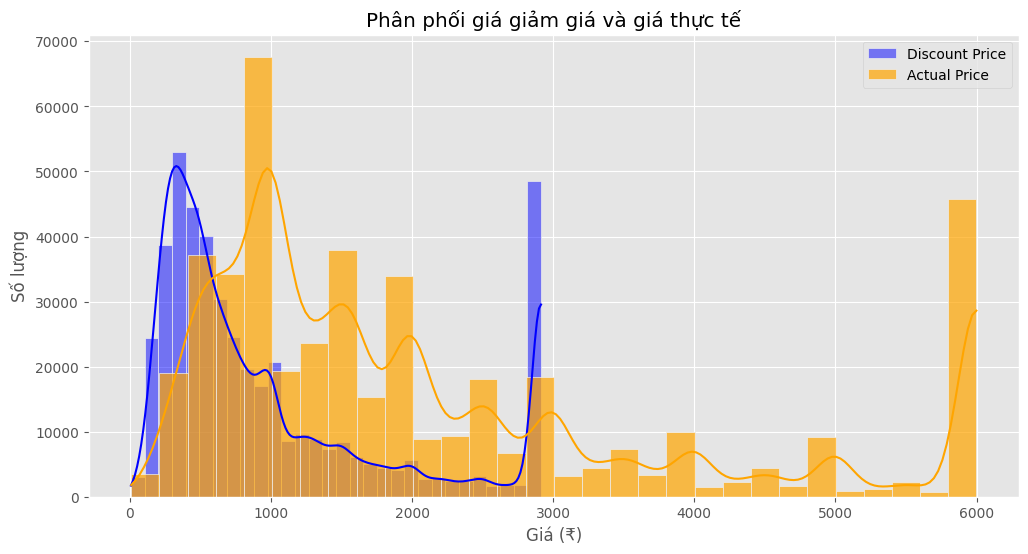

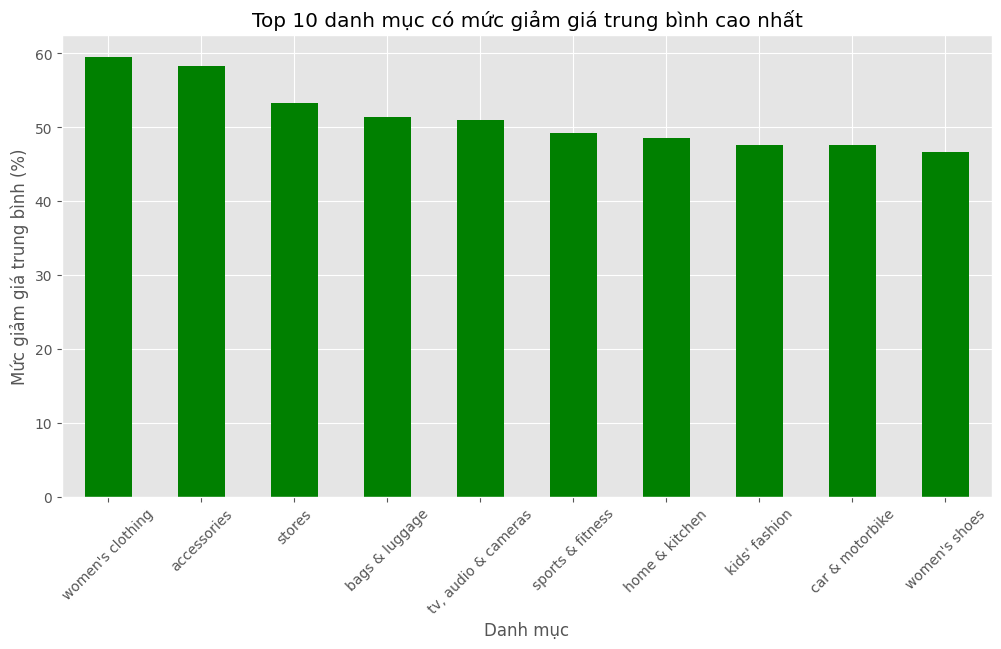

In [58]:
# 1. Phân phối giá giảm giá và giá thực tế
plt.figure(figsize=(12, 6))
sns.histplot(full_data['discount_price'], bins=30, kde=True, color='blue', label='Discount Price')
sns.histplot(full_data['actual_price'], bins=30, kde=True, color='orange', label='Actual Price', alpha=0.7)
plt.title('Phân phối giá giảm giá và giá thực tế')
plt.xlabel('Giá (₹)')
plt.ylabel('Số lượng')
plt.legend()
plt.show()

# 2. Mức giảm giá trung bình theo danh mục
average_discount_by_category = full_data.groupby('main_category')['discount_percentage'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
average_discount_by_category.head(10).plot(kind='bar', color='green')
plt.title('Top 10 danh mục có mức giảm giá trung bình cao nhất')
plt.xlabel('Danh mục')
plt.ylabel('Mức giảm giá trung bình (%)')
plt.xticks(rotation=45)
plt.show()

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Chuẩn bị dữ liệu
# Chọn các cột đặc trưng (features) và cột mục tiêu (target)
features = ['ratings', 'no_of_ratings', 'discount_price', 'discount_percentage']
target = 'actual_price'

# Loại bỏ các hàng có giá trị NaN trong các cột được chọn
data = full_data.dropna(subset=features + [target])

# Tách dữ liệu thành X (features) và y (target)
X = data[features]
y = data[target]

# 2. Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Huấn luyện mô hình hồi quy
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Dự báo trên tập kiểm tra
y_pred = model.predict(X_test)

# 5. Đánh giá mô hình
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

# 6. Hiển thị một số kết quả dự báo
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(results.head())

Mean Squared Error (MSE): 237649.40088440827
R-squared (R2): 0.9203479088998087


,Actual,Predicted
424820,1200.0,1613.779348
465921,799.0,142.966700
340341,4999.0,4399.059511
566029,2299.0,2032.460360
67349,1699.0,1839.401146


In [60]:
# Chọn số cụm
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
full_data["cluster"] = kmeans.fit_predict(X)
# Đặt tên cho các cụm dựa trên đặc điểm nổi bật

cluster_names = {
    0:"Phụ kiện gắn tường cho máy lạnh (AC stands)",
    1:"Thiết bị gia dụng phổ biến",
    2:"Đồ gia dụng giá rẻ / phụ kiện nhỏ",
    3:"Thiết bị gia dụng thông minh",
    4:"Máy lạnh (AC) cao cấp"}
# Xem một số sản phẩm trong mỗi cụm
for i in range(n_clusters):
    print(f"\n🔹 Cụm {i}: {cluster_names[i]}:")
    display(full_data[full_data["cluster"] == i][["name", "discount_price", "ratings"]].head(5))
    


🔹 Cụm 0: Phụ kiện gắn tường cho máy lạnh (AC stands):


,name,discount_price,ratings
123,allwin tafta high quality metal special coated...,647.0,4.45
125,hexzone floor ac stand certified special coate...,679.0,4.10
225,fidel tafta heavy duty air conditioner outdoor...,699.0,3.60
447,qawachh 3 in 1 multi function pet design mist ...,699.0,3.90
595,heavy duty air conditioner outdoor ac stand,899.0,3.90



🔹 Cụm 1: Thiết bị gia dụng phổ biến:


,name,discount_price,ratings
0,lloyd 1.5 ton 3 star inverter split ac (5 in 1...,2914.0,4.2
1,lg 1.5 ton 5 star ai dual inverter split ac (c...,2914.0,4.2
2,lg 1 ton 4 star ai dual inverter split ac (cop...,2914.0,4.2
3,lg 1.5 ton 3 star ai dual inverter split ac (c...,2914.0,4.0
4,carrier 1.5 ton 3 star inverter split ac (copp...,2914.0,4.1



🔹 Cụm 2: Đồ gia dụng giá rẻ / phụ kiện nhỏ:


,name,discount_price,ratings
150,ac stand/heavy duty air conditioner outdoor un...,599.0,4.45
243,hexzone® tafta outdoor ac stand (wall),599.0,3.25
340,risarya h20r1203 igbt 1pcs power transistor 20...,199.0,4.00
720,pigeon by stovekraft amaze plus electric kettl...,599.0,3.90
721,pigeon polypropylene mini handy and compact ch...,199.0,4.10



🔹 Cụm 3: Thiết bị gia dụng thông minh:


,name,discount_price,ratings
439,raptor air conditioner motor 95 watt 910 rpm w...,2400.0,3.9
728,nutripro juicer mixer grinder - smoothie maker...,1990.0,4.1
732,bajaj rex 500w mixer grinder with nutri-pro fe...,2099.0,4.2
743,prestige pic 20 1600 watt induction cooktop wi...,2095.0,4.1
745,pigeon by stovekraft 14429 acer plus 1800 watt...,1799.0,3.8



🔹 Cụm 4: Máy lạnh (AC) cao cấp:


,name,discount_price,ratings
187,threeh usb fan silent mini air conditioner tra...,1219.0,4.0
476,ac outdoor stand for 1 ton and 1.5 ton,1200.0,3.9
725,bajaj frore 1200 mm ceiling fan (brown),1349.0,4.1
729,philips gc1905 1440-watt steam iron with spray...,1699.0,4.3
730,lifelong llmg23 power pro 500-watt mixer grind...,1329.0,3.8


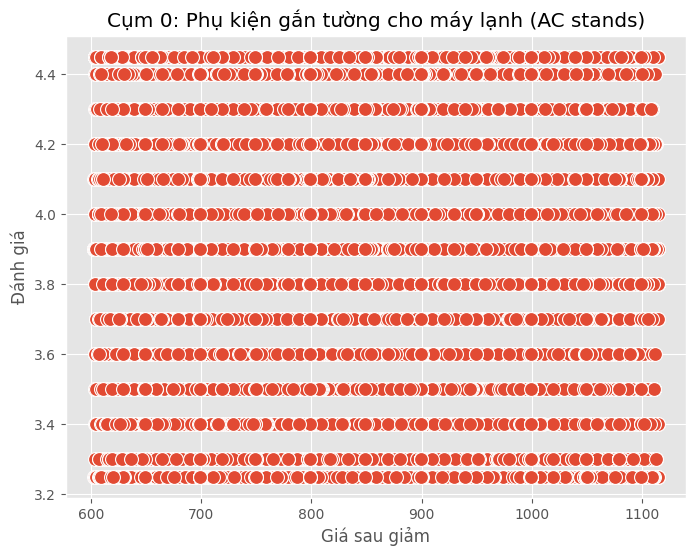

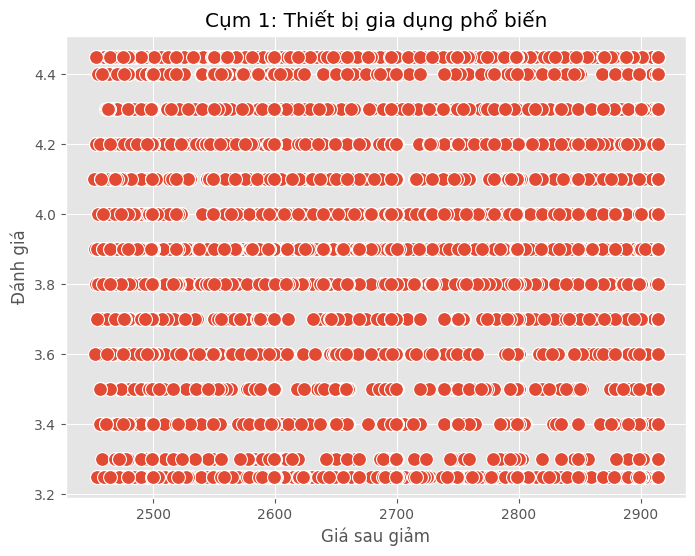

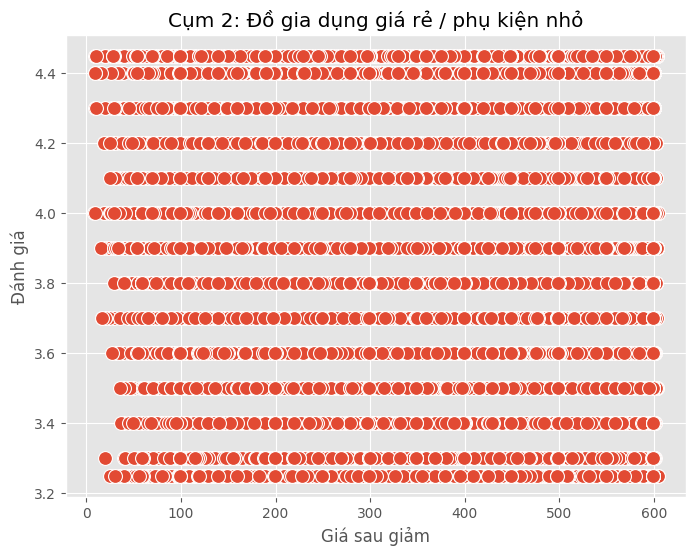

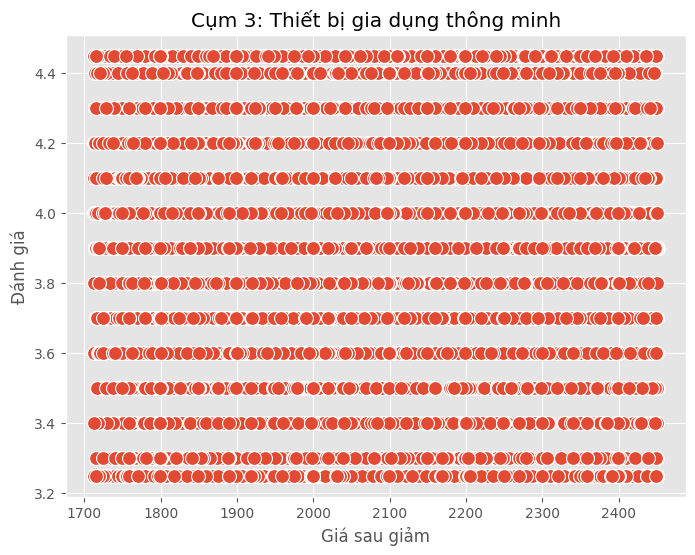

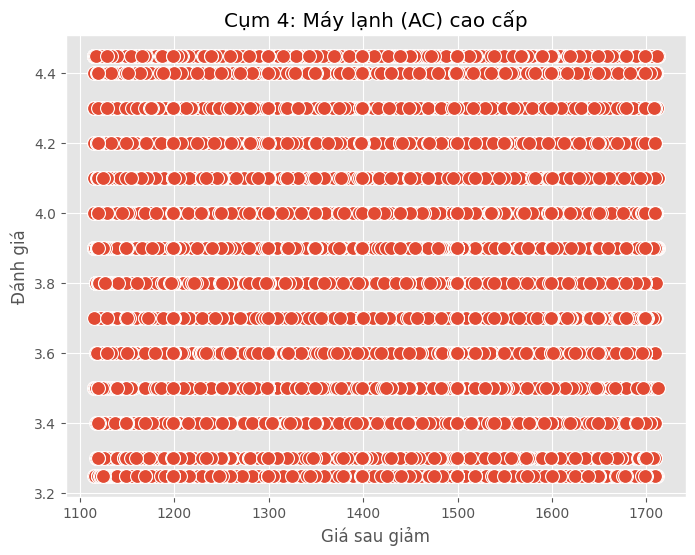

In [61]:
# Tạo từng biểu đồ riêng biệt cho từng cụm
for i in range(5):
    plt.figure(figsize=(8, 6))
    subset = full_data[full_data["cluster"] == i]
    sns.scatterplot(data=subset, x="discount_price", y="ratings", s=100)
    plt.title(f"Cụm {i}: {cluster_names[i]}")
    plt.xlabel("Giá sau giảm")
    plt.ylabel("Đánh giá")
    plt.grid(True)
    plt.show()


In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Huấn luyện mô hình RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# 2. Dự báo trên tập kiểm tra
rf_y_pred = rf_model.predict(X_test)

# 3. Đánh giá mô hình
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"Mean Squared Error (MSE): {rf_mse}")
print(f"R-squared (R2): {rf_r2}")

# 4. Hiển thị một số kết quả dự báo
rf_results = pd.DataFrame({'Actual': y_test, 'Predicted': rf_y_pred})
display(rf_results.head())


Mean Squared Error (MSE): 56.17062395391188
R-squared (R2): 0.999981173494906


,Actual,Predicted
424820,1200.0,1200.00
465921,799.0,798.90
340341,4999.0,4997.92
566029,2299.0,2299.00
67349,1699.0,1699.02


In [63]:
from xgboost import XGBRegressor

# 1. Huấn luyện mô hình XGBoost
xgb_model = XGBRegressor(random_state=42, n_estimators=100)
xgb_model.fit(X_train, y_train)

# 2. Dự báo trên tập kiểm tra
xgb_y_pred = xgb_model.predict(X_test)

# 3. Đánh giá mô hình
xgb_mse = mean_squared_error(y_test, xgb_y_pred)
xgb_r2 = r2_score(y_test, xgb_y_pred)

print(f"Mean Squared Error (MSE): {xgb_mse}")
print(f"R-squared (R2): {xgb_r2}")

# 4. Hiển thị một số kết quả dự báo
xgb_results = pd.DataFrame({'Actual': y_test, 'Predicted': xgb_y_pred})
display(xgb_results.head())

Mean Squared Error (MSE): 3200.514268079616
R-squared (R2): 0.9989272951957807


,Actual,Predicted
424820,1200.0,1190.424561
465921,799.0,787.878906
340341,4999.0,4990.748535
566029,2299.0,2279.036621
67349,1699.0,1727.792480


In [66]:
pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 6.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
from mlxtend.frequent_patterns import apriori, association_rules

# Tạo cột rating_group (phân nhóm điểm đánh giá)
full_data['rating_group'] = pd.cut(
	full_data['ratings'],
	bins=[-float('inf'), 3.5, 4.0, float('inf')],
	labels=['low', 'medium', 'high']
)

# Tạo cột price_group (phân nhóm giá giảm giá)
full_data['price_group'] = pd.cut(
	full_data['discount_price'],
	bins=[-float('inf'), 1000, 3000, float('inf')],
	labels=['low', 'medium', 'high']
)

# Chuyển đổi dữ liệu về dạng one-hot encoding cho các thuộc tính phân loại
basket = pd.get_dummies(full_data[['sub_category', 'main_category', 'rating_group', 'price_group', 'cluster']], columns=['sub_category', 'main_category', 'rating_group', 'price_group', 'cluster'])

# Đảm bảo chỉ lấy các cột one-hot (bỏ cột gốc nếu còn sót lại)
# Nếu vẫn còn cột 'cluster' gốc (dạng số), hãy loại bỏ nó:
basket = basket.loc[:, basket.max() <= 1]

# Tìm các itemsets phổ biến với min_support=0.01 (có thể điều chỉnh)
frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)

# Khai thác luật kết hợp với min_threshold=0.5 (có thể điều chỉnh)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# Hiển thị một số luật kết hợp
display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

,antecedents,consequents,support,confidence,lift
0,(sub_category_all appliances),(main_category_appliances),0.018565,1.000000,15.723863
1,(sub_category_all electronics),"(main_category_tv, audio & cameras)",0.018897,1.000000,7.344368
2,(sub_category_all electronics),(rating_group_high),0.010955,0.579700,2.254888
3,(sub_category_all electronics),(price_group_low),0.012324,0.652133,0.945587
4,(sub_category_all electronics),(cluster_2),0.010053,0.531997,1.103828
5,(sub_category_bags & luggage),(main_category_accessories),0.037983,1.000000,4.928016
6,(sub_category_bags & luggage),(price_group_low),0.027371,0.720625,1.044899
7,(sub_category_bags & luggage),(cluster_2),0.020244,0.532976,1.105858
8,(sub_category_camera accessories),"(main_category_tv, audio & cameras)",0.019728,1.000000,7.344368
9,(sub_category_camera accessories),(price_group_low),0.013378,0.678118,0.983265


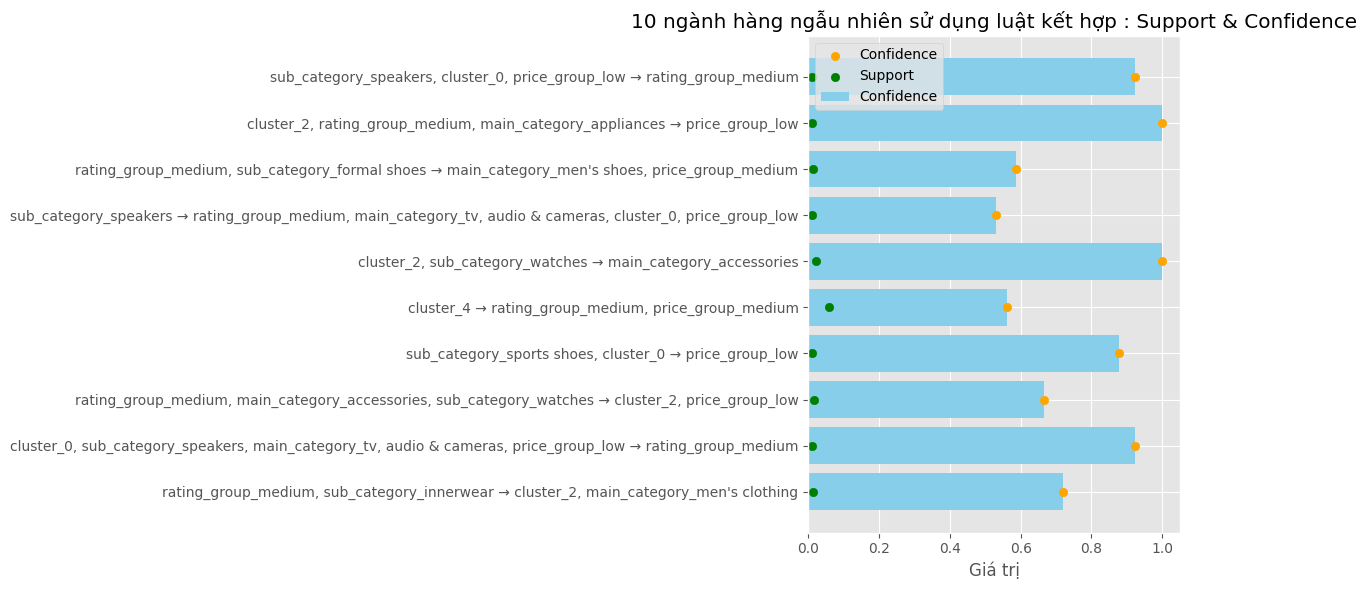

In [85]:
import random

# Lấy 10 chỉ số ngẫu nhiên từ rules
random_indices = random.sample(range(len(rules)), 10)
sampled_rules = rules.iloc[random_indices]

# Vẽ biểu đồ thể hiện support và confidence của 10 luật ngẫu nhiên
plt.figure(figsize=(12, 6))
plt.barh(
    [f"{', '.join([str(x) for x in row['antecedents']])} → {', '.join([str(x) for x in row['consequents']])}" for _, row in sampled_rules.iterrows()],
    sampled_rules['confidence'],
    color='skyblue',
    label='Confidence'
)
plt.scatter(
    sampled_rules['confidence'],
    range(10),
    color='orange',
    label='Confidence'
)
plt.scatter(
    sampled_rules['support'],
    range(10),
    color='green',
    label='Support'
)
plt.xlabel('Giá trị')
plt.title('10 ngành hàng ngẫu nhiên sử dụng luật kết hợp : Support & Confidence')
plt.legend()
plt.tight_layout()
plt.show()

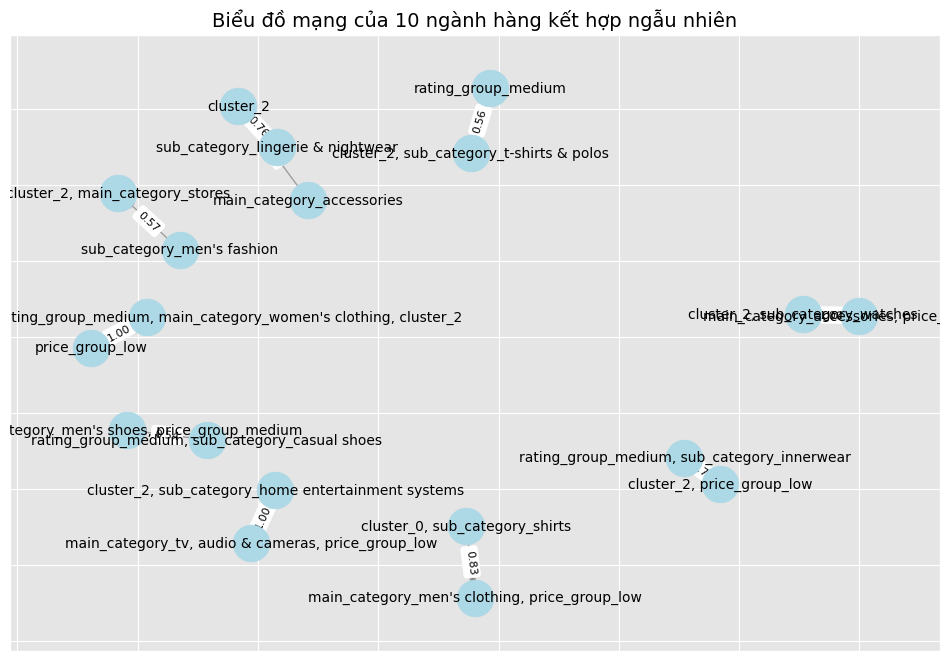

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Lấy 10 ngành hàng ngẫu nhiên từ `rules`
random_rules = rules.sample(10, random_state=42)

# Tạo đồ thị
G = nx.DiGraph()

# Thêm các cạnh (edges) từ luật kết hợp
for _, row in random_rules.iterrows():
    antecedents = ', '.join(list(row['antecedents']))
    consequents = ', '.join(list(row['consequents']))
    G.add_edge(antecedents, consequents, weight=row['confidence'])

# Vẽ đồ thị
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # Bố cục đồ thị
edges = G.edges(data=True)

# Vẽ các nút, cạnh và nhãn
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_edges(G, pos, edgelist=edges, width=1, alpha=0.7, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')

# Thêm nhãn cho các cạnh (confidence)
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Biểu đồ mạng của 10 ngành hàng kết hợp ngẫu nhiên", fontsize=14)
plt.show()